<a href="https://colab.research.google.com/github/Cristobal2506/MineriaDeDatos/blob/main/proyecto_base_mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Información del Grupo

Integrante 1:
Cristobal Muñoz
cra.munozr@duocuc.cl

Integrante 2:
Nixy Silva
nix.silva@duocuc.cl

Seccion: 004D


Link dataset: https://archive.ics.uci.edu/dataset/352/online+retail






# Tema del proyecto

Clasificación de transacciones de venta como devoluciones o ventas válidas en una tienda de retail online, a partir de variables transaccionales como cantidad, precio unitario, fecha y producto.


# Descripción del Proyecto

El presente proyecto analiza un dataset transaccional real de una tienda de retail online con sede en el Reino Unido, que operó entre diciembre de 2010 y diciembre de 2011. El dataset contiene 541.909 registros de compras individuales, incluyendo información sobre boletas, productos, clientes y países.

El fenómeno a estudiar es la detección automática de transacciones que corresponden a devoluciones o cancelaciones, diferenciándolas de las ventas legítimas. Esto resulta crítico para los equipos de marketing y operaciones, ya que las devoluciones impactan directamente en los ingresos reales, la gestión de inventario y la evaluación de campañas comerciales.

¿Para qué sirve este modelo?

Permite a los equipos de marketing depurar automáticamente su base de datos de transacciones antes de calcular métricas de desempeño.
Ayuda a identificar patrones de devolución por producto, país o período, permitiendo ajustar estrategias de venta.
Automatiza un proceso que hoy se realiza manualmente mediante revisión de prefijos en el número de boleta (C indica cancelación).


# Introducción a la Metodología

Este proyecto sigue la metodología CRISP-DM (Cross Industry Standard Process for Data Mining), estándar ampliamente adoptado en la industria para abordar proyectos de ciencia de datos. Sus seis fases son:

Comprensión del Negocio — Definir el objetivo desde una perspectiva práctica.
Comprensión de los Datos — Explorar la fuente, estructura y calidad del dataset.
Preparación de los Datos — Limpiar, transformar y codificar variables.
Análisis Exploratorio — Visualizar patrones y generar hipótesis.
Modelado — Seleccionar y entrenar el algoritmo adecuado.
Evaluación — Medir el desempeño del modelo con métricas apropiadas.

## 1. Comprensión del Negocio
El objetivo práctico de este proyecto es construir un clasificador binario capaz de determinar si una transacción corresponde a una venta válida o a una devolución/cancelación, usando únicamente las variables disponibles en el sistema transaccional.

Actualmente, la única forma de identificar devoluciones es revisar si el InvoiceNo comienza con la letra C, lo que es un proceso manual y propenso a errores cuando se trabaja con grandes volúmenes de datos exportados o integrados desde otros sistemas.

Decisión que se espera mejorar:
Automatizar la clasificación de transacciones para que los reportes de ventas netas sean más confiables y rápidos de generar, permitiendo al equipo de marketing tomar decisiones basadas en datos correctos.

## 2. Comprensión de los Datos

### Fuente del Dataset
- **Nombre:** Online Retail Dataset
- **Origen:** UCI Machine Learning Repository
- **URL:** https://archive.ics.uci.edu/dataset/352/online+retail
- **Licencia:** Creative Commons Attribution 4.0 (CC BY 4.0)
- **Autores:** Daqing Chen, London South Bank University (2015)

### Descripción de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| `InvoiceNo` | Nominal | ID único de boleta. Si comienza con 'C', es cancelación |
| `StockCode` | Nominal | Código único de producto |
| `Description` | Nominal | Nombre del producto |
| `Quantity` | Numérico | Cantidad de unidades por transacción |
| `InvoiceDate` | Fecha/Hora | Fecha y hora de la transacción |
| `UnitPrice` | Numérico | Precio unitario en libras esterlinas (£) |
| `CustomerID` | Nominal | ID único del cliente |
| `Country` | Categórico | País de residencia del cliente |



In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [31]:
#Tamaño del dataset
df.shape

(541909, 8)

In [32]:
#Tipos de datos
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


# Estadistica descriptiva a las variables numericas

In [33]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 3. Preparación de los Datos
Detalle los pasos de limpieza y transformación de datos.

- Eliminación de nulos
- Conversión de categorías
- Normalización o estandarización

In [34]:
#Identificacion de valores nulos
for feature in df.columns:
  print('Total de valores nulos de', feature, '-', df[feature].isna().sum())

Total de valores nulos de InvoiceNo - 0
Total de valores nulos de StockCode - 0
Total de valores nulos de Description - 1454
Total de valores nulos de Quantity - 0
Total de valores nulos de InvoiceDate - 0
Total de valores nulos de UnitPrice - 0
Total de valores nulos de CustomerID - 135080
Total de valores nulos de Country - 0


In [35]:
# Eliminacion de nulos
df = df.dropna()
df.shape

(406829, 8)

#### 3.1 Depuración de Datos
- Manejo de valores nulos
- Detección y tratamiento de outliers
- Corrección de errores de tipeo

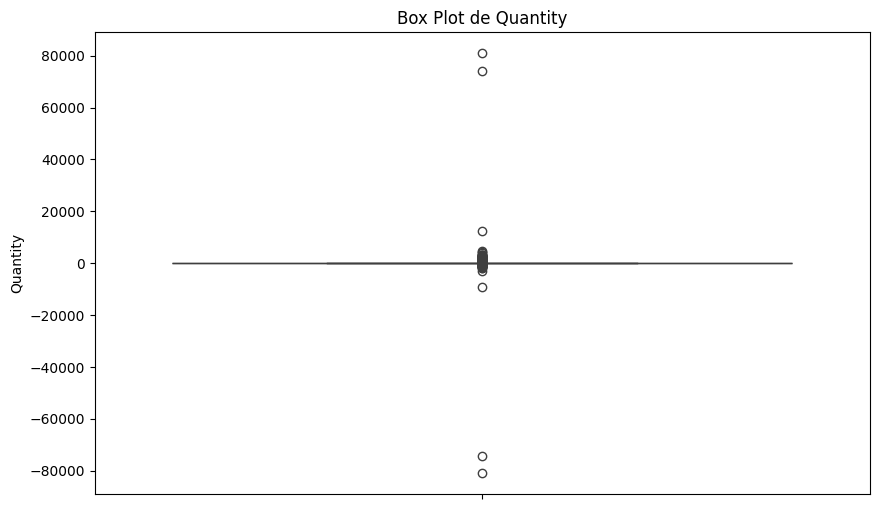

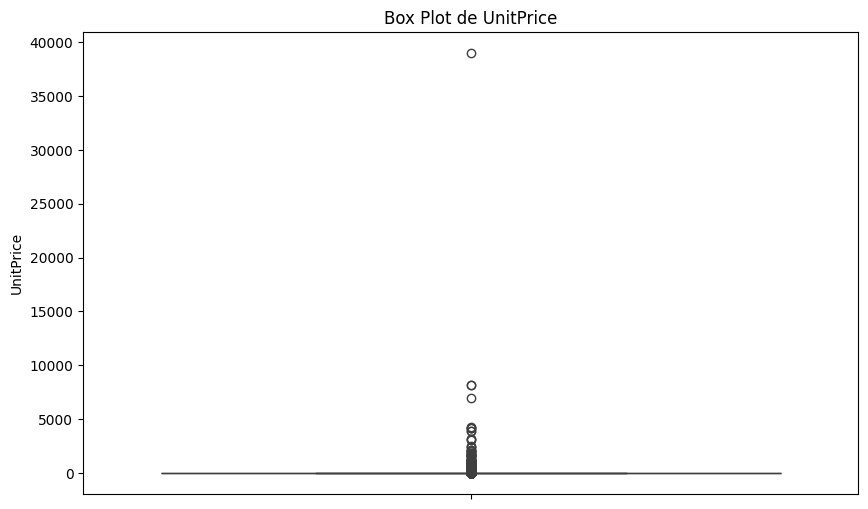

In [36]:
# Box plot para 'Quantity'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Quantity'])
plt.title('Box Plot de Quantity')
plt.ylabel('Quantity')
plt.show()

# Box plot para 'UnitPrice'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['UnitPrice'])
plt.title('Box Plot de UnitPrice')
plt.ylabel('UnitPrice')
plt.show()

Los box plots muestran claramente la presencia de muchos valores atípicos, tanto en `Quantity` como en `UnitPrice`. Vamos a cuantificarlos usando el método IQR.

In [37]:
# Función para detectar outliers usando IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detección de outliers en 'Quantity'
outliers_quantity, lb_q, ub_q = detect_outliers_iqr(df, 'Quantity')
print(f"Outliers en Quantity (valores por debajo de {lb_q} o por encima de {ub_q}):")
print(f"Total de outliers de Quantity: {len(outliers_quantity)}")
print(f"Porcentaje de outliers de Quantity: {len(outliers_quantity) / len(df) * 100:.2f}%")

# Detección de outliers en 'UnitPrice'
outliers_unitprice, lb_up, ub_up = detect_outliers_iqr(df, 'UnitPrice')
print(f"\nOutliers en UnitPrice (valores por debajo de {lb_up} o por encima de {ub_up}):")
print(f"Total de outliers de UnitPrice: {len(outliers_unitprice)}")
print(f"Porcentaje de outliers de UnitPrice: {len(outliers_unitprice) / len(df) * 100:.2f}%")

Outliers en Quantity (valores por debajo de -13.0 o por encima de 27.0):
Total de outliers de Quantity: 26682
Porcentaje de outliers de Quantity: 6.56%

Outliers en UnitPrice (valores por debajo de -2.5 o por encima de 7.5):
Total de outliers de UnitPrice: 36051
Porcentaje de outliers de UnitPrice: 8.86%


Como se observa, hay una cantidad significativa de outliers en ambas columnas. Para `Quantity`, los valores negativos (que ya sabemos que son devoluciones) se clasifican como outliers. Para `UnitPrice`, los valores cero o muy altos también son detectados. Dependiendo del objetivo específico del modelo, se decidirá si se eliminan, se transforman o se mantienen estos outliers.

In [38]:
# Tamaño del DataFrame antes de eliminar outliers
print('Shape original:', df.shape)

# Eliminar outliers para 'Quantity' y 'UnitPrice'
# Mantener solo las filas donde Quantity está dentro de los límites
df_cleaned = df[(df['Quantity'] >= lb_q) & (df['Quantity'] <= ub_q)]

# Luego, aplicar el filtro de UnitPrice sobre el DataFrame ya filtrado por Quantity
df_cleaned = df_cleaned[(df_cleaned['UnitPrice'] >= lb_up) & (df_cleaned['UnitPrice'] <= ub_up)]

# Tamaño del DataFrame después de eliminar outliers
print('Shape después de eliminar outliers:', df_cleaned.shape)

display(df_cleaned.head())

Shape original: (406829, 8)
Shape después de eliminar outliers: (344393, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Hemos creado un nuevo DataFrame llamado `df_cleaned` con los outliers eliminados.

#### 3.2 Encoding (si aplica)
- Transformaciones aplicadas a variables categóricas (OneHotEncoding, LabelEncoding, etc.)


In [39]:
# Aplicar One-Hot Encoding a la columna de "country" para posterior analisis
df_listo = pd.get_dummies(df_cleaned, columns=['Country'], drop_first=True)


In [40]:
df_listo.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country_Austria,Country_Bahrain,Country_Belgium,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False


## 4. Análisis Exploratorio
Describa con texto y **agregue gráficos** del análisis.

- Histogramas
- Correlaciones
- Boxplots
- Distribuciones por clase

In [41]:
df_listo.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country_Austria,Country_Bahrain,Country_Belgium,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False


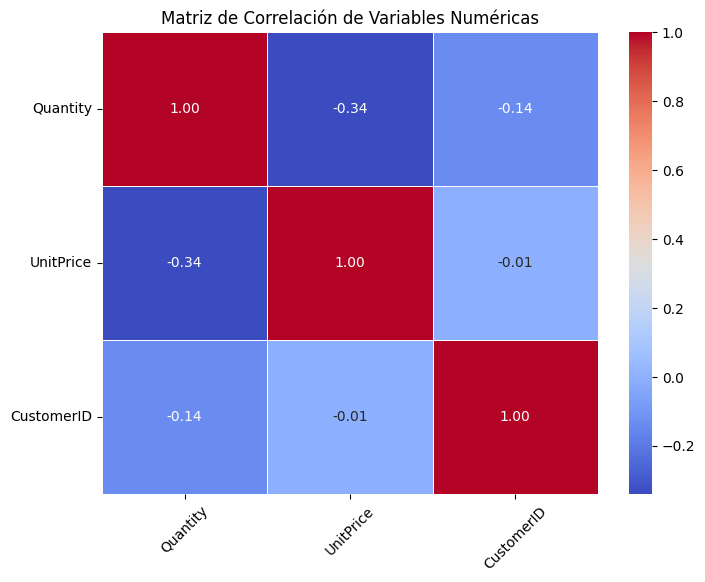

In [48]:
cols_relevantes = ['Quantity', 'UnitPrice', 'CustomerID']
correlation_matrix = df_listo[cols_relevantes].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Distribución de `Quantity` y `UnitPrice` (Histograms)

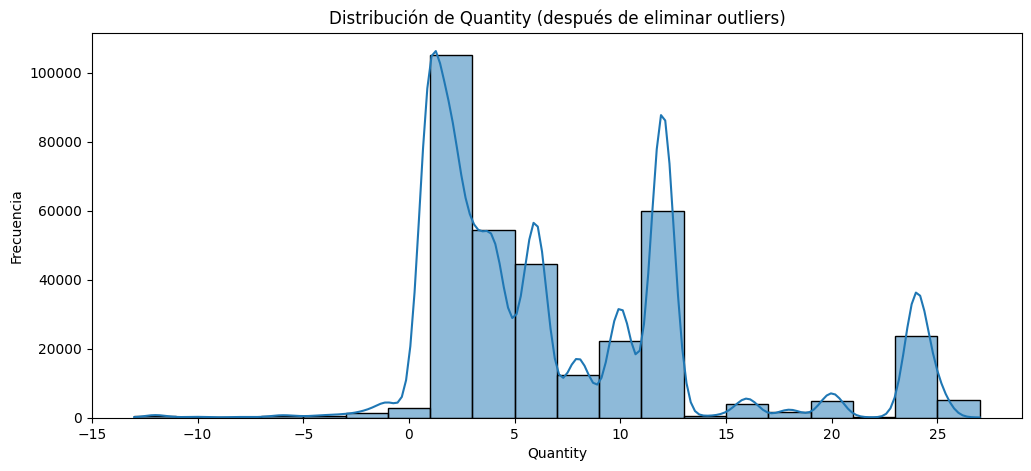

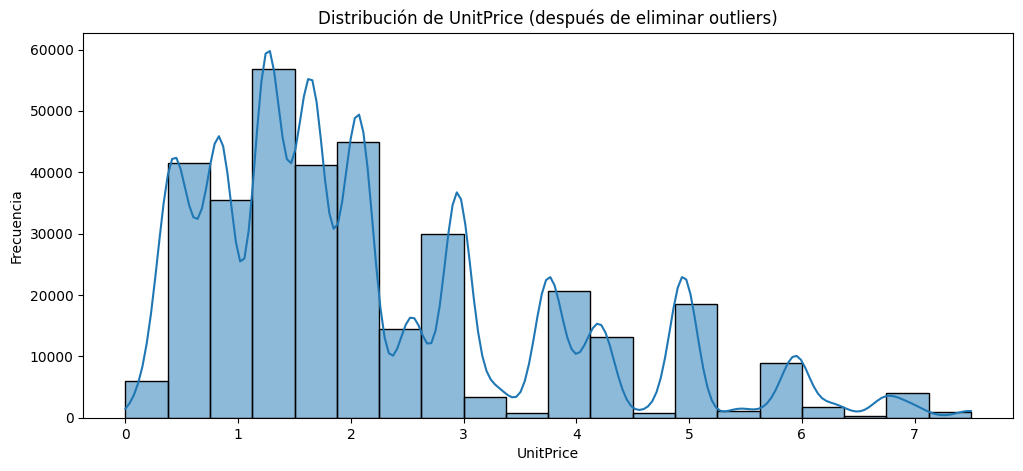

In [49]:
plt.figure(figsize=(12, 5))
sns.histplot(df_listo['Quantity'], bins=20, kde=True)
plt.title('Distribución de Quantity (después de eliminar outliers)')
plt.xlabel('Quantity')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df_listo['UnitPrice'], bins=20, kde=True)
plt.title('Distribución de UnitPrice (después de eliminar outliers)')
plt.xlabel('UnitPrice')
plt.ylabel('Frecuencia')
plt.show()

### Distribución de Ventas por País

Dado que hemos aplicado One-Hot Encoding a la columna `Country`, para visualizar la distribución por país, usaremos el DataFrame `df_cleaned` antes de la codificación para obtener los nombres originales de los países.

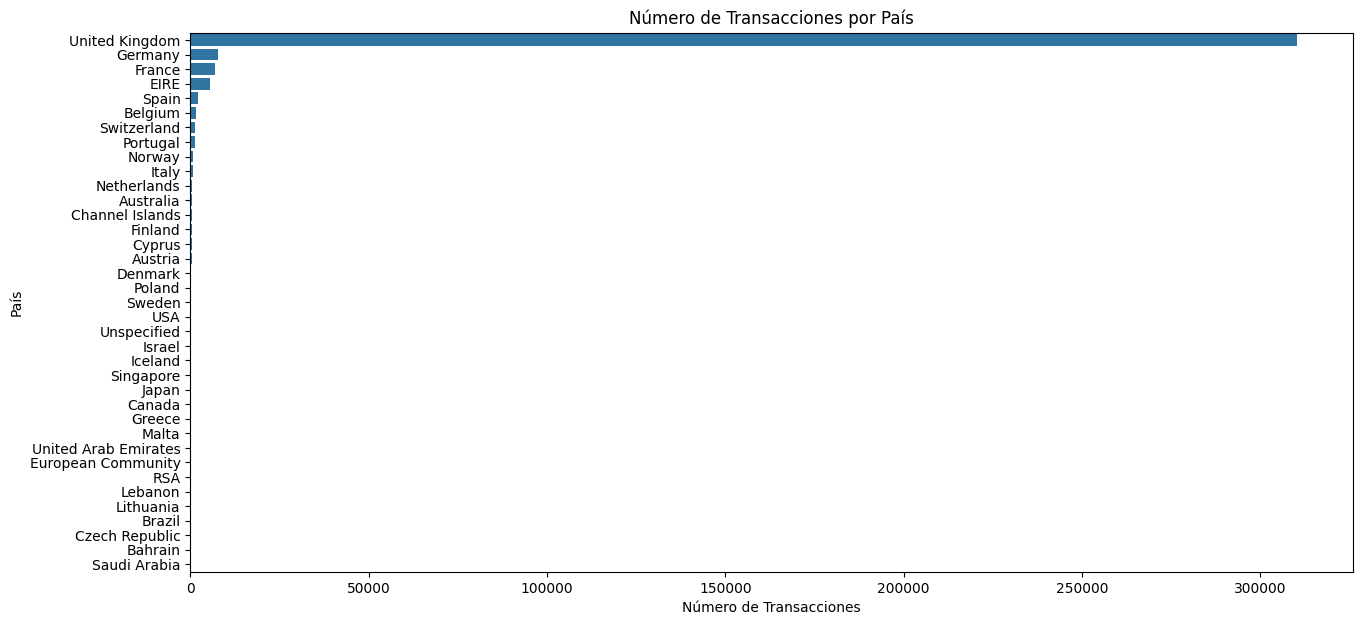

In [50]:
plt.figure(figsize=(15, 7))
sns.countplot(y=df_cleaned['Country'], order=df_cleaned['Country'].value_counts().index)
plt.title('Número de Transacciones por País')
plt.xlabel('Número de Transacciones')
plt.ylabel('País')
plt.show()

### Análisis de Ventas a lo largo del Tiempo

Vamos a agregar las ventas diarias para observar la tendencia a lo largo del período del dataset.

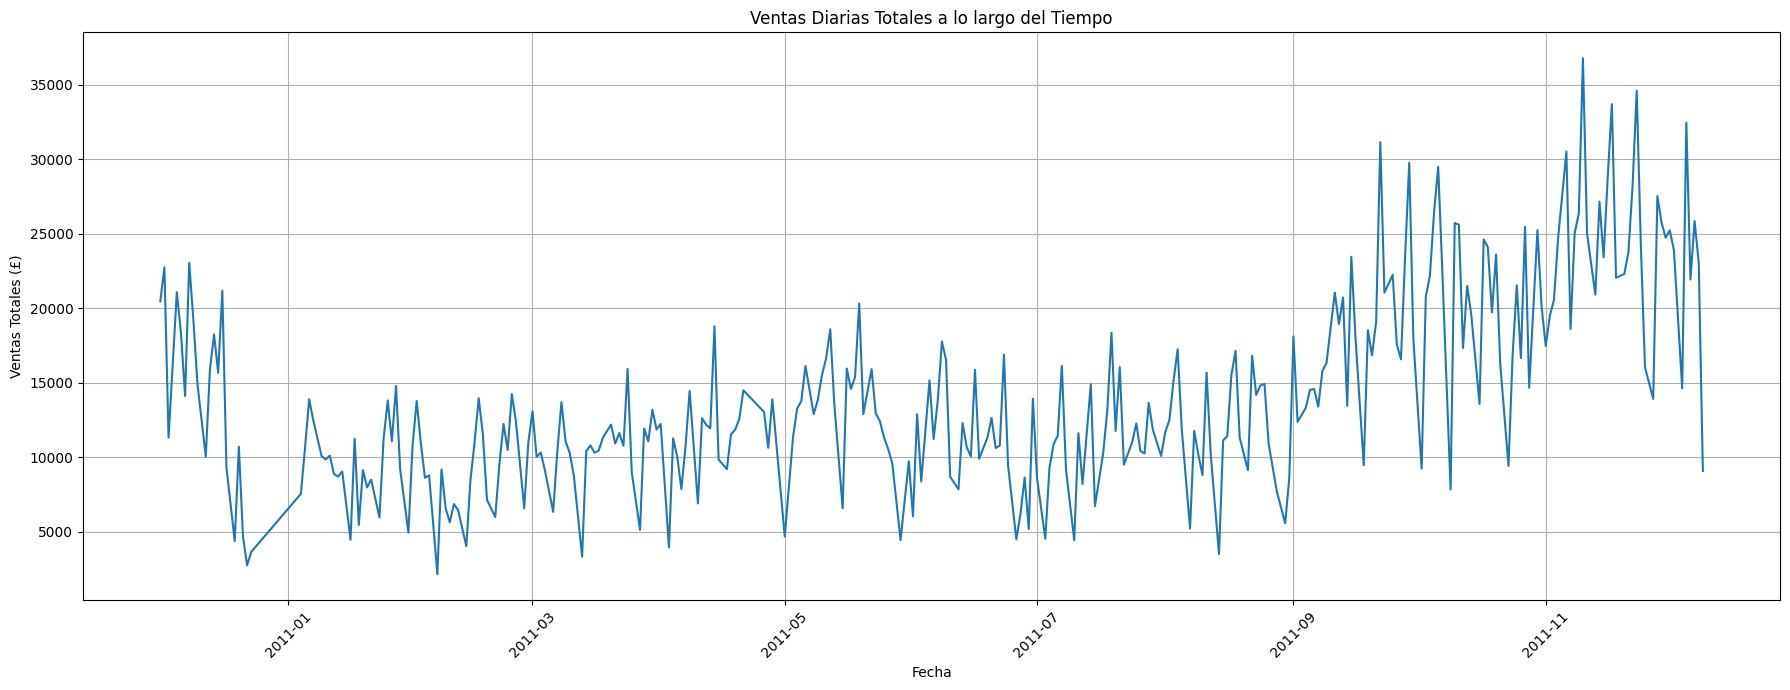

In [51]:
# Calcular el total de ventas (Quantity * UnitPrice)
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

# Agrupar por fecha y sumar el TotalPrice
daily_sales = df_cleaned.groupby(df_cleaned['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales['InvoiceDate'] = pd.to_datetime(daily_sales['InvoiceDate'])

plt.figure(figsize=(18, 7))
sns.lineplot(x='InvoiceDate', y='TotalPrice', data=daily_sales)
plt.title('Ventas Diarias Totales a lo largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales (£)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Este mapa de calor muestra la correlación entre `Quantity` y `UnitPrice`. Los valores cercanos a 1 o -1 indican una correlación fuerte positiva o negativa, respectivamente, mientras que los valores cercanos a 0 indican poca o ninguna correlación lineal.

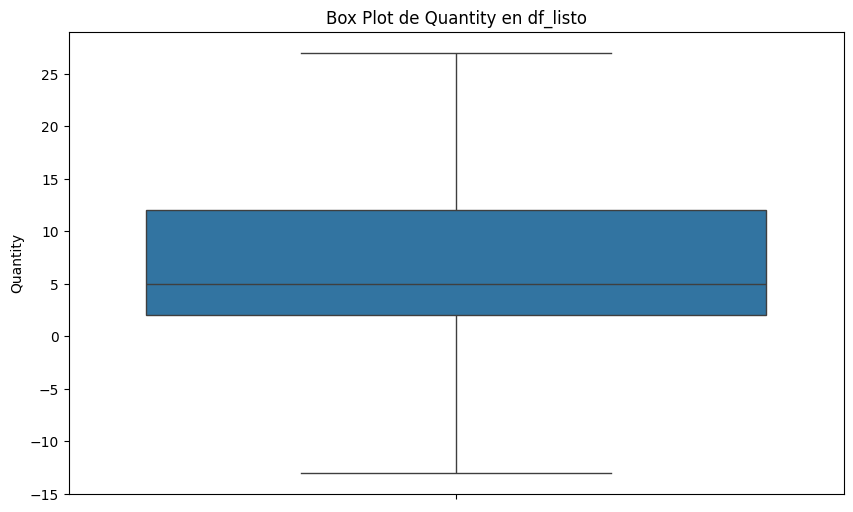

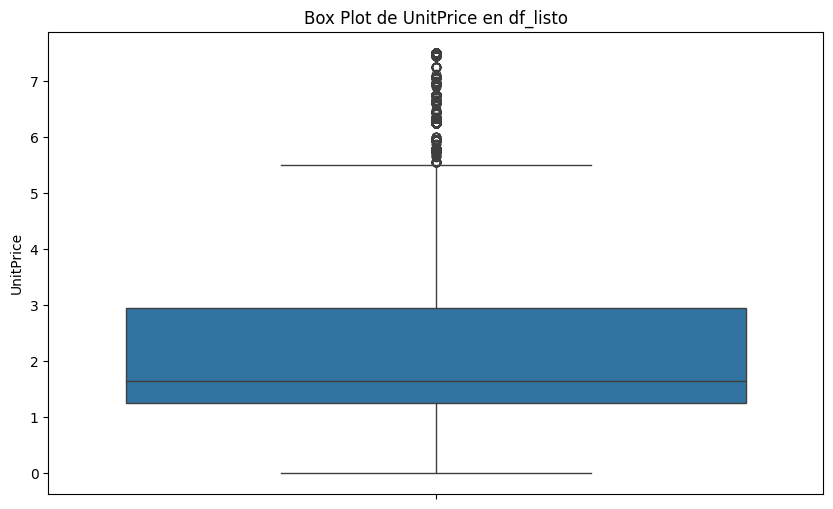

In [43]:
# Box plot para 'Quantity' en df_listo
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_listo['Quantity'])
plt.title('Box Plot de Quantity en df_listo')
plt.ylabel('Quantity')
plt.show()

# Box plot para 'UnitPrice' en df_listo
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_listo['UnitPrice'])
plt.title('Box Plot de UnitPrice en df_listo')
plt.ylabel('UnitPrice')
plt.show()

## 5. Modelado
Especifique si se trata de clasificación o regresión y qué modelo(s) ha utilizado:

- Regresión lineal / logística
- Árbol de decisión
- KNN / SVM / Random Forest

In [44]:
# Escriba aqui sus codigos

## 6. Entrenamiento y Evaluación
Describa los pasos del entrenamiento del modelo, conjunto de entrenamiento y prueba, métricas utilizadas (Accuracy, RMSE, R², etc.)


In [45]:
# Escriba aqui sus codigos

## 7. Despliegue (opcional)
Explique cómo podría usarse el modelo en una aplicación real o simule un ejemplo.


In [46]:
# Escriba aqui sus codigos

## 8. Conclusiones
Resumen de hallazgos, utilidad del modelo, recomendaciones futuras.

In [47]:
# Escriba aqui sus codigos